# Multi-AMBIT + LR1-B capture, gated on PAR stability

The AMBIT counterpart to `multi_minipar_lr1b_capture.ipynb`. Several AMBITs and one LR1-B
reference spectrometer are discovered, then read together: **binary command 35
(`get_spec_raw`) is issued to every AMBIT simultaneously**, and once all of their PAR
readings hold steady at the same time, that instant is recorded together with an LR1-B
reference spectrum.

### What is different from the MiniPAR notebook

| | MiniPAR notebook | this notebook |
|---|---|---|
| transport | text console, one line per reply | **binary wire protocol** (`0xA0` + 8 B -> `0xA1` + payload + `0xF0`) |
| spectral read | `spec_raw` (text) | **cmd 35 `get_spec_raw`** - unscaled counts + the acquisition parameters they were taken under |
| stability gate | TIA PAR + every MiniPAR's spectral total | **every AMBIT's PAR**, simultaneously |
| settings | randomised per device, per capture | fixed in firmware (gain 2x, ATIME 99, ASTEP 499) and *reported* by cmd 35 |
| reference PAR sensor | TIA on its own COM port | none - the AMBITs' own PAR is the quantity under test |

### Why cmd 35 rather than cmd 31

Cmd 31 (`get_spec`) reports each channel as `counts x Spec_COE` packed into a `uint16`.
Those weights are 12, 10, 11, 10, 10, 9, 7, 4, 1, 1, so the word overflows 16 bits from
about 11 % of ADC full scale - F1 tops out above 5461 of 50000 counts. Firmware before
v1.2.0 let that **wrap**, so a bright reading came back looking like a dark one; v1.2.0
saturates it at 65535 instead. Either way the channel words stop being usable well before
the sensor does.

Cmd 35 reports the **unscaled** counts, which cannot overflow (full scale is
`(ATIME+1) x (ASTEP+1)` = 50000 < 65535), plus `atime`, `astep`, both bank gains and a
saturation flag - everything needed to normalise across exposures. See
`plans/HW_CONFORMANCE.md` section 6 for the byte layout.

> **Firmware requirement: an image containing `get_spec_raw`.** Section 5 establishes that
> by *asking each device once*, with a short timeout, rather than by trusting the version
> number. It has to: `tools/version.py` takes only the leading `X.Y.Z` of `git describe`,
> so a development build sitting three commits past the tag still reports **1.1.4** in the
> cmd 33/2 struct even when it does serve cmd 35. The version is displayed for information
> and used to word the error, never to gate.
>
> A one-off probe is affordable; a per-sample one is not, which is why the capability is
> resolved once at startup and the capture loop never re-checks.

### Connections

AMBITs are USB CDC serial, one COM port each. The **LR1-B is USB HID**, not a COM port, so
it can never collide with the serial scan; it is driven through [`lr1b.py`](lr1b.py) and
needs `pip install hidapi`. It is optional - without it the capture still runs and the
LR1-B columns are left empty.

## 1 - Imports and configuration

In [24]:
import json
import re
import struct
import sys
import threading
import time
from collections import deque
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import serial
from serial.tools import list_ports
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from IPython.display import clear_output, display

sys.path.insert(0, str(Path.cwd()))

LR1B = autogain = LR1B_IMPORT_ERROR = None


def _diagnose_hid():
    """Explain a failed `import hid` in the terms that actually fix it.

    The usual cause is not a missing wheel but two installed at once. The `hid`
    PyPI package installs a *directory*, cython-hidapi (`hidapi`) installs an
    *extension module* - and in the same site-packages a package always wins over
    a file module. So `import hid` picks the wrong one, which then fails trying to
    ctypes-load hidapi.dll, and the symptom reads as "the module is missing".
    """
    import glob
    import importlib.util
    import os

    notes = [f'kernel interpreter : {sys.executable}']
    try:
        spec = importlib.util.find_spec('hid')
    except Exception:
        spec = None
    if spec is None or not spec.origin:
        notes.append('no `hid` module on sys.path -> %pip install hidapi')
        return notes

    notes.append(f'`import hid` resolves to : {spec.origin}')
    is_package = bool(spec.submodule_search_locations)
    search_dir = os.path.dirname(os.path.dirname(spec.origin) if is_package
                                 else spec.origin)
    ext = sorted(glob.glob(os.path.join(search_dir, 'hid.*.pyd'))
                 + glob.glob(os.path.join(search_dir, 'hid.*.so')))
    if is_package and ext:
        notes.append(f'CONFLICT: the `hid` package directory shadows '
                     f'{os.path.basename(ext[0])} (cython-hidapi) in the same '
                     f'site-packages. A package always wins over a file module, so '
                     f'the incompatible wrapper is what gets imported.')
        notes.append('fix: %pip uninstall -y hid     # keep hidapi, drop the shadow')
        notes.append('     then re-run load_lr1b()')
    elif is_package:
        notes.append('this is the incompatible `hid` wrapper and cython-hidapi is not '
                     'installed -> %pip uninstall -y hid && %pip install hidapi')
    else:
        notes.append('this is the right module but it failed to load - check that the '
                     'wheel matches the kernel interpreter above')
    return notes


def load_lr1b(verbose=False):
    """(Re)attempt the lr1b import and publish LR1B / autogain / LR1B_IMPORT_ERROR.

    A function rather than a bare try/except so that installing the wheel does not
    cost a kernel restart: `pip install hidapi` in a running kernel leaves this
    cell's earlier verdict stale. lr1b.py raises during import when `hid` is
    missing, so it never reaches sys.modules - but a half-initialised `hid` can,
    so both are dropped before retrying.
    """
    global LR1B, autogain, LR1B_IMPORT_ERROR
    for name in ('lr1b', 'hid'):
        sys.modules.pop(name, None)
    try:
        import lr1b as _lr1b
        LR1B, autogain, LR1B_IMPORT_ERROR = _lr1b.LR1B, _lr1b.autogain, None
    except Exception as exc:               # hidapi missing, or lr1b.py not alongside
        LR1B, autogain, LR1B_IMPORT_ERROR = None, None, exc
    if verbose:
        if LR1B is not None:
            print('LR1-B module: ready')
        else:
            print(f'LR1-B module: unavailable - {LR1B_IMPORT_ERROR}')
            for note in _diagnose_hid():
                print('  ', note)
    return LR1B is not None


load_lr1b()

BAUD_RATE = 115200

# --- AMBIT binary wire protocol (src/run_esp.cpp; framing is frozen) --------
CMD_HEADER, CMD_DONE, CMD_END = 0xA0, 0xA1, 0xF0
WAKE_BYTE, WAKE_ACK, IDLE_HEARTBEAT = 0xAA, 0x80, 0x85

CMD_GET_SPEC, CMD_GET_TEMP, CMD_GET_INFO, CMD_GET_SPEC_RAW = 31, 32, 33, 35
INFO_CALIBRATION, INFO_FW, INFO_METADATA = 1, 2, 3
RESP_SPEC_SIZE, RESP_TEMP_SIZE, RESP_FW_SIZE, RESP_SPEC_RAW_SIZE = 24, 4, 48, 32

# get_spec_raw is released in v1.2.0, but the version alone cannot decide this:
# tools/version.py keeps only the leading X.Y.Z of `git describe`, so a dev build
# three commits past the tag reports 1.1.4 while serving cmd 35 perfectly well.
# Section 5 probes each device once instead; this is only used to word the error.
MIN_FW_SPEC_RAW = (1, 2, 0)
SPEC_RAW_PROBE_TIMEOUT = 2.5               # s; an image without the opcode never replies
SPEC_RAW_FORMAT = 1                        # payload[0]; bump means a layout change

AS7341_TICK_S = 2.78e-6                    # ADC step period

# Channel order is cmd 35's raw[10] wire order: F1..F8, then NIR, then Clear.
# This is NOT the MiniPAR CSV order (which ends '... clear, nir') - swapping the
# last two would silently mislabel two columns in every saved row.
SPECTRAL_CHANNELS = ['f1_415', 'f2_445', 'f3_480', 'f4_515',
                     'f5_555', 'f6_590', 'f7_630', 'f8_680',
                     'nir', 'clear']
N_SPEC = len(SPECTRAL_CHANNELS)

# The per-channel weights cmd 31 applies to these same counts
# (src/src/as7341/spec_meas.cpp SPEC_WEIGHT).
SPEC_WEIGHTS = [12, 10, 11, 10, 10, 9, 7, 4, 1, 1]

# --- CSV schema -------------------------------------------------------------
ACQ_COLUMNS  = ['atime', 'astep', 'gain_low', 'gain_high', 'gain_x', 'tint_ms',
                'full_scale']
SAT_COLUMNS  = ['sat_flag', 'headroom', 'saturated_channels']
STAB_COLUMNS = ['par_spread', 'par_ptp', 'n_samples', 'stable']
LR1B_COLUMNS = ['lr1b_exposure_ms', 'lr1b_peak', 'lr1b_total', 'lr1b_peak_nm',
                'lr1b_spectrum_file']
CSV_COLUMNS  = (['timestamp', 'measurement', 'ambit', 'metadata', 'par', 'temp_leaf']
                + SPECTRAL_CHANNELS + ACQ_COLUMNS + SAT_COLUMNS + STAB_COLUMNS
                + LR1B_COLUMNS)

# --- Where readings are stored ---------------------------------------------
_here = Path.cwd()
DATA_DIR = _here.parent / 'data' if (_here.parent / 'data').is_dir() else _here / 'data'
CSV_PATH = DATA_DIR / 'multi_ambit_spec_lr1b.csv'
LR1B_DIR = DATA_DIR / 'lr1b_spectra_ambit'

# --- Stability criterion (gated on PAR, as the capture design calls for) ----
STABLE_WINDOW   = 4        # consecutive samples that must agree
STABLE_TOL      = 0.01     # peak-to-peak / mean, per device
STABLE_MAX_WAIT = 120.0    # s before giving up and returning the last window
SETTLE_S        = 0.10     # pause between samples
PAR_ABS_FLOOR   = 1.0      # PAR units: a window flatter than this counts as stable
                           # even when the *relative* spread is large, which is what
                           # happens near darkness where PAR itself is ~0
SPEC_ABS_FLOOR  = 8.0      # counts; reported for information, does not gate
LR1B_ABS_FLOOR  = 50.0     # LR1-B total counts

# --- LR1-B ------------------------------------------------------------------
LR1B_TARGET_COUNTS = 20_000
LR1B_FULL_SCALE    = 65535
LR1B_EXPOSURE_MIN  = 0.01
LR1B_EXPOSURE_MAX  = 2000.0
LR1B_GATES_STABILITY   = False   # read, but never holds up a capture
LR1B_READ_EVERY_SAMPLE = False   # the design is: gate on AMBIT PAR, then take one
                                 # spectrum. Set True to read it every sample so its
                                 # exposure overlaps the AMBIT integrations instead.

READ_TEMP = True                 # also log leaf temperature (cmd 32) per capture

# Discovery results, filled in by the scan in section 3. Declared here so the cells
# below can be re-run in isolation without depending on the scan having run first.
AMBIT_PORTS, AMBIT_PROBE, AMBIT_LINES = [], {}, {}
LR1B_PRESENT = False

print(f'CSV target : {CSV_PATH}')
print(f'LR1-B dir  : {LR1B_DIR}')
print(f'Stability  : {STABLE_WINDOW} PAR samples within {STABLE_TOL * 100:.1f} % on every '
      f'AMBIT at the same time'
      + (', LR1-B included' if LR1B_GATES_STABILITY else ' (LR1-B excluded)'))
print(f'Firmware   : cmd {CMD_GET_SPEC_RAW} (get_spec_raw) is probed per device in '
      f'section 5, not inferred from the version')
if LR1B is None:
    print('LR1-B      : unavailable - capture will run without it. Diagnosis:')
    for note in _diagnose_hid():
        print('             ', note)

CSV target : c:\Users\LudovicoCaracciolo\Documents\Git-repo\ambit\data\multi_ambit_spec_lr1b.csv
LR1-B dir  : c:\Users\LudovicoCaracciolo\Documents\Git-repo\ambit\data\lr1b_spectra_ambit
Stability  : 4 PAR samples within 1.0 % on every AMBIT at the same time (LR1-B excluded)
Firmware   : cmd 35 (get_spec_raw) is probed per device in section 5, not inferred from the version


### If the LR1-B reported as unavailable

`lr1b.py` needs the **cython-hidapi** wheel, distributed on PyPI as `hidapi`, which
publishes an extension module called `hid`.

**The usual failure is not a missing wheel but two of them installed at once.** The
similarly named `hid` package on PyPI is a different, incompatible wrapper, and it installs
a *directory* named `hid/`. In one site-packages a package directory always wins over a
file module, so `hid/` shadows cython-hidapi's `hid.cp312-win_amd64.pyd`; the wrapper is
imported instead, fails to `ctypes`-load `hidapi.dll`, and the symptom reads as *"the 'hid'
module is missing"* even though the right wheel is installed. `load_lr1b(verbose=True)`
detects exactly this and prints the fix:

```
%pip uninstall -y hid      # drop the shadowing wrapper, keep hidapi
```

If neither is installed, `%pip install hidapi`. Prefer `%pip` over `!pip`: the magic
installs into the kernel's own interpreter, whereas `!pip` uses whatever `pip` the shell
resolves, which need not be the same environment.

Either way, installing in a running kernel leaves the verdict above stale, because the
import was attempted before the wheel existed. Re-run the cell below rather than restarting
the kernel - `load_lr1b()` drops the cached `lr1b`/`hid` modules and retries.

In [25]:
load_lr1b(verbose=True)

LR1-B module: ready


True

## 2 - The binary wire protocol

Every binary command is `0xA0` followed by exactly 8 bytes, whatever the opcode; the reply
is `0xA1`, a fixed-length payload, then `0xF0`. All multi-byte fields are little-endian.

`full_scale` is *not* a constant - the integration time sets it, so at short exposures a
channel tops out well below 65535. The firmware's own `SPEC_FULL_SCALE` omits the 65535
cap because at its fixed 99/499 it evaluates to 50000 and the cap never binds; the host
formula keeps the cap so it stays correct if the exposure ever changes.

In [26]:
def gain_multiplier(gain_reg):
    """AS7341 GAIN register -> multiplier: 0 -> 0.5x, n -> 2**(n-1)."""
    gain_reg = int(gain_reg)
    return 0.5 if gain_reg == 0 else float(1 << (gain_reg - 1))


def integration_time_s(atime, astep):
    return (int(atime) + 1) * (int(astep) + 1) * AS7341_TICK_S


def full_scale_counts(atime, astep):
    """ADC full scale for this exposure, capped at the 16-bit counter."""
    return min(0xFFFF, (int(atime) + 1) * (int(astep) + 1))


def basic_counts(raw, gain_reg, atime, astep):
    """Gain- and exposure-normalised counts, comparable across settings."""
    divisor = gain_multiplier(gain_reg) * integration_time_s(atime, astep)
    raw = np.asarray(raw, dtype=float)
    return raw / divisor if divisor else raw


def build_frame(opcode, *payload):
    """0xA0 + 8 command bytes. Every binary command is this same fixed length."""
    body = list(payload)
    if len(body) > 7:
        raise ValueError('a command carries at most 7 argument bytes')
    body += [0] * (7 - len(body))
    return bytes([CMD_HEADER, int(opcode) & 0xFF] + [int(b) & 0xFF for b in body])


def decode_spec_raw(payload):
    """cmd 35 -> dict. Layout per plans/HW_CONFORMANCE.md section 6."""
    if len(payload) != RESP_SPEC_RAW_SIZE:
        raise ValueError(f'get_spec_raw: expected {RESP_SPEC_RAW_SIZE} bytes, '
                         f'got {len(payload)}')
    fmt, atime, gain_low, gain_high = payload[0], payload[1], payload[2], payload[3]
    if fmt != SPEC_RAW_FORMAT:
        raise RuntimeError(f'get_spec_raw returned format {fmt}; this notebook reads '
                           f'format {SPEC_RAW_FORMAT}. The payload layout has changed.')
    astep, flags = struct.unpack_from('<HH', payload, 4)
    raw = np.array(struct.unpack_from('<10H', payload, 8), dtype=float)
    par = struct.unpack_from('<f', payload, 28)[0]

    fs = full_scale_counts(atime, astep)
    return {
        'format': int(fmt), 'atime': int(atime), 'astep': int(astep),
        'gain_low': int(gain_low), 'gain_high': int(gain_high),
        'gain_x': gain_multiplier(gain_low), 'flags': int(flags),
        'sat_flag': bool(flags & 1), 'raw': raw, 'par': float(par),
        'full_scale': fs, 'tint_ms': integration_time_s(atime, astep) * 1e3,
        'headroom': 1.0 - float(raw.max()) / fs if fs else 0.0,
        'saturated_channels': [n for n, c in zip(SPECTRAL_CHANNELS, raw) if c >= fs],
    }


def decode_spec(payload):
    """cmd 31 -> dict. The ten words are counts x SPEC_WEIGHTS, saturated at 65535
    from v1.2.0 (they wrapped before that), so they are only meaningful below the
    rail. Kept for cross-checking cmd 35, not for capture."""
    if len(payload) != RESP_SPEC_SIZE:
        raise ValueError(f'get_spec: expected {RESP_SPEC_SIZE} bytes, got {len(payload)}')
    words = np.array(struct.unpack_from('<10H', payload, 0), dtype=float)
    par = struct.unpack_from('<f', payload, 20)[0]
    return {'words': words, 'par': float(par),
            'clamped': [n for n, w in zip(SPECTRAL_CHANNELS, words) if w >= 0xFFFF]}


def decode_temp(payload):
    """cmd 32 -> (leaf degC, chip degC). Two int16, both scaled by 10."""
    if len(payload) != RESP_TEMP_SIZE:
        raise ValueError(f'get_temp: expected {RESP_TEMP_SIZE} bytes, got {len(payload)}')
    leaf, chip = struct.unpack('<hh', payload)
    return leaf / 10.0, chip / 10.0


def format_mac(mac_u64):
    """ESP.getEfuseMac() packs the 6-byte MAC into a uint64.

    Returns (low-byte-first, high-byte-first) - the two orderings tools disagree
    on. Both are reported in the inventory table so you can match whichever your
    fleet records use; only one is chosen for the label.
    """
    lo = ':'.join(f'{(int(mac_u64) >> (8 * i)) & 0xFF:02X}' for i in range(6))
    hi = ':'.join(f'{(int(mac_u64) >> (8 * i)) & 0xFF:02X}' for i in range(5, -1, -1))
    return lo, hi


def decode_fw_info(payload):
    """cmd 33/2 -> dict. 48 bytes at frozen offsets (ESP32 default alignment):
    3 x uint8 version, pad, uint32 size, uint64 MAC, char[12] date, uint8 hw_rev,
    char[11] reserved, uint8 checksum."""
    if len(payload) != RESP_FW_SIZE:
        raise ValueError(f'get_info/2: expected {RESP_FW_SIZE} bytes, got {len(payload)}')
    (major, minor, batch, size, mac, date,
     hw_rev, _reserved, checksum) = struct.unpack('<BBBxIQ12sB11sB7x', payload)
    mac_lo, mac_hi = format_mac(mac)
    return {'version': (int(major), int(minor), int(batch)),
            'version_str': f'{major}.{minor}.{batch}',
            'size': int(size), 'mac_u64': int(mac),
            'mac': mac_lo, 'mac_reversed': mac_hi,
            'fw_date': date.split(b'\x00')[0].decode(errors='ignore').strip(),
            'hw_rev': int(hw_rev), 'checksum': int(checksum)}


def supports_spec_raw(version):
    return tuple(version) >= MIN_FW_SPEC_RAW


print('Protocol helpers ready.')
print('  cmd 35 frame ->', build_frame(CMD_GET_SPEC_RAW).hex(' '))
print('  full scale at the firmware default (ATIME 99, ASTEP 499):',
      full_scale_counts(99, 499), 'counts,',
      f'{integration_time_s(99, 499) * 1e3:.0f} ms per bank')

Protocol helpers ready.
  cmd 35 frame -> a0 23 00 00 00 00 00 00 00
  full scale at the firmware default (ATIME 99, ASTEP 499): 50000 counts, 139 ms per bank


## 3 - Find the instruments

**The control lines have to be driven differently depending on how the AMBIT is attached,
and the two requirements are opposites:**

| attachment | port looks like | DTR/RTS |
|---|---|---|
| CH9102 / CP210x / FTDI **bridge** | `USB-Enhanced-SERIAL CH9102`, vendor wch.cn | must stay **low** - they are wired to the C3's EN and IO9 straps, so asserting them reboots the board (and a reboot prints the banner plus the NVS dump straight into whatever we are parsing) |
| **native USB CDC** | `USB Serial Device`, Microsoft `usbser.sys` | DTR must be **asserted** - there is no reset circuit, and DTR is the CDC line-state signal that tells the device a terminal is attached. With it low the firmware's USB stack never transmits and the port looks dead |

So each port is probed under both line states rather than assuming one. The state that
worked is remembered per port and reused when the link is opened for real - getting it
wrong does not produce an error, it produces silence, which is indistinguishable from "not
an AMBIT".

Identification tries the text console first: `hello` answers `NEW <name> Ready FW:<version>`,
which names the device *and* proves the console is alive, in one exchange.

**A text probe alone is not enough**, so it falls back to binary cmd 33/2. A device that was
last used on an ambyte comes up latched to `HOST_BINARY` and light-sleeping: it ignores the
text console until it reboots, and its first bytes are swallowed while it wakes. The
fallback therefore tries cmd 33/2 cold, and then again after the `0xAA` wake preamble. Any
of the three identifies an AMBIT; the method used is reported, since a device found only by
the wake path will keep light-sleeping between commands.

The LR1-B is enumerated over HID and never appears as a COM port, so it cannot collide with
this scan.

In [27]:
def serial_ports():
    """Every COM port the OS knows about (pyserial, so no helpers.py dependency)."""
    return sorted(p.device for p in list_ports.comports())


def _read_until_quiet(ser, quiet_s=0.35, max_s=2.5):
    """Read everything the port sends until it has been silent for `quiet_s`."""
    chunks, deadline, last = [], time.monotonic() + max_s, time.monotonic()
    while time.monotonic() < deadline:
        data = ser.read_all()
        if data:
            chunks.append(data)
            last = time.monotonic()
        elif time.monotonic() - last >= quiet_s:
            break
        time.sleep(0.05)
    return b''.join(chunks).decode(errors='ignore')


BANNER_RE = re.compile(r'^NEW\s+(?P<name>.*?)\s+Ready(?:\s+FW:(?P<fw>\S+))?\s*$')


def parse_banner(banner):
    """`NEW <name> Ready FW:<version>` -> (name, version string or '')."""
    match = BANNER_RE.match(banner.strip())
    if not match:
        return '', ''
    return (match.group('name') or '').strip(), (match.group('fw') or '').strip()


def _read_binary_reply(ser, resp_len, timeout):
    """0xA1 + resp_len + 0xF0, skipping anything that precedes CMD_DONE."""
    deadline = time.monotonic() + timeout
    while time.monotonic() < deadline:
        b = ser.read(1)
        if not b:
            continue
        if b[0] == CMD_DONE:
            payload = ser.read(resp_len)
            tail = ser.read(1)
            if len(payload) == resp_len and tail and tail[0] == CMD_END:
                return payload
            return None
    return None


# (dtr, rts) states to try, in order. Low-first is deliberate: on a bridge board it
# is the only safe state, and on a native-CDC board it merely yields silence, which
# costs one round of the probe. The reverse order could reboot a bridge board.
LINE_STATES = ((False, False), (True, False))


def _probe_one_state(ser, timeout):
    """Try every dialect at the current line state. -> (method, banner, info) or None."""
    # 1. text console
    ser.reset_input_buffer()
    ser.write(b'hello\n')
    ser.flush()
    time.sleep(0.4)
    text = _read_until_quiet(ser)
    banner = next((l.strip() for l in text.splitlines()
                   if l.strip().startswith('NEW') and 'Ready' in l), None)
    if banner:
        return 'text', banner, None

    # 2. binary cmd 33/2 - answers even when the console will not
    for method, preamble in (('binary', b''), ('wake+binary', bytes([WAKE_BYTE]) * 3)):
        ser.reset_input_buffer()
        if preamble:
            ser.write(preamble)
            ser.flush()
            time.sleep(0.3)
            ser.reset_input_buffer()
        ser.write(build_frame(CMD_GET_INFO, INFO_FW))
        ser.flush()
        payload = _read_binary_reply(ser, RESP_FW_SIZE, 1.5)
        if payload:
            try:
                return method, None, decode_fw_info(payload)
            except Exception:
                pass
    return None


def probe_ambit(port, timeout=2.0, settle=0.8):
    """Identify `port` as an AMBIT under whichever line state and dialect answers.

    Returns (method, (dtr, rts), banner_or_None, fw_info_or_None), or a str
    explaining why not - 'busy' is a very different thing from 'not an AMBIT' and
    the caller should be able to say which.

    'hello' is terminated by the firmware's 200 ms input timeout, not by the
    newline: Serial_Input_Chars() treats only ':' and ',' as terminators and
    strips CR/LF. So allow for that pause before reading.
    """
    for dtr, rts in LINE_STATES:
        try:
            with serial.Serial(port, baudrate=BAUD_RATE, timeout=timeout) as ser:
                ser.dtr, ser.rts = dtr, rts
                time.sleep(settle)
                found = _probe_one_state(ser, timeout)
                if found:
                    method, banner, info = found
                    return method, (dtr, rts), banner, info
        except (OSError, serial.SerialException) as exc:
            # Almost always "port already open" - a serial monitor or another
            # notebook still holds it. Worth saying so rather than reporting the
            # port as "not an AMBIT", which sends you looking at the wrong thing.
            return f'unavailable ({type(exc).__name__}: {exc})'
    return 'silent under both line states'


def port_hint(port):
    """One line about how the port is attached, to explain the DTR requirement."""
    info = next((p for p in list_ports.comports() if p.device == port), None)
    if info is None:
        return ''
    return f'{info.description} [{info.manufacturer or "?"}]'


print('Scanning serial ports...')
ports = serial_ports()
print(f'  {len(ports)} port(s): {", ".join(ports) if ports else "none"}')

AMBIT_PORTS, AMBIT_PROBE, AMBIT_LINES = [], {}, {}
for port in ports:
    result = probe_ambit(port)
    if isinstance(result, str):
        print(f'  {port}: {result}   ({port_hint(port)})')
        continue
    method, lines, banner, info = result
    AMBIT_PORTS.append(port)
    AMBIT_PROBE[port] = method
    AMBIT_LINES[port] = lines
    dtr_note = 'DTR low' if not lines[0] else 'DTR asserted'
    if banner:
        name, fw = parse_banner(banner)
        print(f'  {port}: [{method}, {dtr_note}] {banner}')
        print(f'          -> name={name!r} fw={fw or "(not reported)"}  '
              f'({port_hint(port)})')
    else:
        print(f'  {port}: [{method}, {dtr_note}] fw {info["version_str"]} '
              f'mac {info["mac"]} - text console silent, so this device is '
              f'probably ambyte-latched   ({port_hint(port)})')
print(f'\n{len(AMBIT_PORTS)} AMBIT(s): {", ".join(AMBIT_PORTS) or "none"}')

print('\nLooking for the LR1-B (USB HID, never a COM port)...')
LR1B_PRESENT = False
if LR1B is None:
    print(f'  lr1b unavailable: {LR1B_IMPORT_ERROR}')
else:
    found = LR1B.list_devices()
    for info in found:
        print(f"  serial {info['serial_number']}  {info['manufacturer_string']} "
              f"{info['product_string']}")
    LR1B_PRESENT = bool(found)
    if not found:
        # hid.enumerate() lists a device whether or not something holds it open, so
        # an empty result means the LR1-B is not on the USB bus at all - it has not
        # merely been claimed by another program. Power is the usual reason: several
        # ESP32 boards plus a spectrometer behind one unpowered hub exceeds what the
        # host port supplies, and the spectrometer is the heaviest load of the set.
        print('  none found - the device is absent from the USB bus, not just busy.')
        print('  * a running ASEQ application would NOT hide it here (it would still')
        print('    enumerate, and only opening it would fail), so suspect the link:')
        print('  * on an unpowered hub, move the LR1-B to a powered hub or a port')
        print('    directly on the machine, then re-run this cell')
        try:
            import hid as _hid
            print(f'  * {len(_hid.enumerate())} HID device(s) visible in total, so '
                  f'hidapi itself is working - this is a connection problem')
        except Exception:
            pass

Scanning serial ports...
  3 port(s): COM61, COM71, COM72
  COM61: [text, DTR asserted] NEW AmbitV003 Ready FW:1.1.4-3-ga1ff230-dirty
          -> name='AmbitV003' fw=1.1.4-3-ga1ff230-dirty  (USB Serial Device (COM61) [Microsoft])
  COM71: [text, DTR low] NEW AmbitV003 Ready FW:1.1.4-3-ga1ff230-dirty
          -> name='AmbitV003' fw=1.1.4-3-ga1ff230-dirty  (USB-Enhanced-SERIAL CH9102 (COM71) [wch.cn])
  COM72: [text, DTR low] NEW AmbitV003 Ready FW:1.1.4-3-ga1ff230-dirty
          -> name='AmbitV003' fw=1.1.4-3-ga1ff230-dirty  (USB-Enhanced-SERIAL CH9102 (COM72) [wch.cn])

3 AMBIT(s): COM61, COM71, COM72

Looking for the LR1-B (USB HID, never a COM port)...
  serial ASQ_SPC2949148  ASEQ Instruments Spectrometer


In [28]:
# Override here if the scan missed something, e.g.
# AMBIT_PORTS = ['COM72', 'COM73']

assert AMBIT_PORTS, ('No AMBIT found - check the USB hub / cabling, or set AMBIT_PORTS by '
                     'hand. A device already latched to an ambyte answers 0x80 to a wake '
                     'byte but ignores the text console until it next reboots.')
if not LR1B_PRESENT:
    print('WARNING: no LR1-B. Captures will run without a reference spectrum.')
print(f'{len(AMBIT_PORTS)} AMBIT(s) @ {", ".join(AMBIT_PORTS)}   '
      f'LR1-B: {"yes" if LR1B_PRESENT else "no"}')

3 AMBIT(s) @ COM61, COM71, COM72   LR1-B: yes


## 4 - Serial / HID layer

Every port is opened **once** and held open - reopening re-asserts DTR/RTS, resets the board
and costs a second or more, which is unusable inside a stability loop.

**The wake byte is deliberately never sent.** `0xAA` latches the firmware into
`HOST_BINARY`, which opts into light sleep between commands. That is right for an ambyte,
which re-sends its wake until acked, and wrong for a PC host, whose next frame would be
eaten by a sleeping UART. Left unlatched (`HOST_UNKNOWN`) or text-latched by the `hello`
probe, the AMBIT never sleeps and answers every frame. `Ambit.wake()` is kept for recovery
if a device arrives already latched from an ambyte.

Each device owns its own port and its own lock, so the capture loop can drive all of them
from a thread pool concurrently.

In [29]:
class Ambit:
    """Persistent connection to one AMBIT (ESP32-C3, USB CDC on UART0).

    The AMBIT speaks three dialects on the one port, selected by first byte: >127
    is the binary ambyte FSM, '{' or '[' is the openJII JSON envelope, and any
    other printable byte is the text console. This class uses the text console
    for the identity handshake and the binary path for acquisition.
    """

    def __init__(self, port, baudrate=BAUD_RATE, timeout=8.0, lines=None):
        self.port = port
        self.label = port                    # placeholder until identify() runs
        self._lock = threading.Lock()
        # Reuse the line state the scan proved works on this port. Defaulting to
        # both-low is right for a bridge board and silent on a native-CDC one, so
        # never guess when the scan already answered.
        self.dtr, self.rts = lines or AMBIT_LINES.get(port, (False, False))
        self.ser = serial.Serial(port, baudrate=baudrate, timeout=timeout)
        self.ser.dtr = self.dtr
        self.ser.rts = self.rts
        time.sleep(0.5)
        self.ser.write(b'\n')                # close any partial line in the firmware buffer
        self.ser.flush()
        self._drain()

        # The text banner is the nicest identity (it carries the NVS name), but it is
        # not required: an ambyte-latched device ignores the console entirely. Binary
        # cmd 33/2 is the authoritative identity and always answers.
        self.banner = self.hello()
        self.name, self.banner_fw = parse_banner(self.banner) if self.banner else ('', '')
        try:
            self.info = self.fw_info()
        except Exception as exc:
            self.close()
            raise RuntimeError(f'{port} did not answer as an AMBIT '
                               f'(no text banner and no cmd 33/2 reply: {exc})') from exc
        self.label = self.identify()
        self.has_spec_raw = None        # resolved by probe_spec_raw() in section 5

    def __repr__(self):
        return f'<{self.label} on {self.port} fw {self.info["version_str"]}>'

    def close(self):
        try:
            self.ser.close()
        except Exception:
            pass

    # -- text console -------------------------------------------------------
    def _drain(self, quiet_s=0.3, max_s=4.0):
        deadline, last = time.monotonic() + max_s, time.monotonic()
        while time.monotonic() < deadline:
            if self.ser.read_all():
                last = time.monotonic()
            elif time.monotonic() - last >= quiet_s:
                return
            time.sleep(0.05)

    def hello(self, attempts=3):
        for _ in range(attempts):
            with self._lock:
                self._drain()
                self.ser.write(b'hello\n')
                self.ser.flush()
                time.sleep(0.4)
                text = self.ser.read_all().decode(errors='ignore')
            for line in text.splitlines():
                line = line.strip()
                if line.startswith('NEW') and 'Ready' in line:
                    return line
        return None

    # -- binary path --------------------------------------------------------
    def _binary(self, opcode, resp_len, args=(), extra=b'', timeout=6.0):
        """0xA0 + 8 B -> 0xA1 + resp_len + 0xF0.

        `args` are the command bytes cmd_arr[1..7] - a sub-command selector for the
        commands that take one. `extra` is trailing payload written after the frame.

        Everything before CMD_DONE is discarded: a 0x85 idle heartbeat from a
        device that was previously ambyte-latched, or console ASCII left over
        from a reboot, must never be read as payload.
        """
        with self._lock:
            self.ser.reset_input_buffer()
            self.ser.write(build_frame(opcode, *args) + extra)
            self.ser.flush()

            deadline, skipped = time.monotonic() + timeout, bytearray()
            while time.monotonic() < deadline:
                b = self.ser.read(1)
                if not b:
                    continue
                if b[0] == CMD_DONE:
                    break
                skipped.append(b[0])
            else:
                # A bare CMD_END with no CMD_DONE is a specific, recognisable
                # answer: the firmware took the opcode but rejected its argument
                # (cmd 33's `else` branch writes exactly this for a sub-command
                # that is not 1/2/3). Say so - it points at the caller, not the wire.
                if set(skipped) == {CMD_END}:
                    hint = (f' - the device answered END with no DONE, which is how it '
                            f'rejects an unrecognised sub-command byte; cmd {opcode} was '
                            f'sent with args={tuple(args)}')
                elif not skipped and opcode == CMD_GET_SPEC_RAW:
                    hint = (' - no reply at all, which is what firmware without this '
                            'opcode does')
                else:
                    hint = ''
                raise TimeoutError(f'{self.label}: cmd {opcode} got no CMD_DONE within '
                                   f'{timeout:g} s{hint}'
                                   + (f' (skipped {bytes(skipped[:16])!r})'
                                      if skipped and set(skipped) != {CMD_END} else ''))

            payload = self.ser.read(resp_len)
            if len(payload) != resp_len:
                raise IOError(f'{self.label}: cmd {opcode} returned {len(payload)}/'
                              f'{resp_len} payload bytes')
            tail = self.ser.read(1)
            if not tail or tail[0] != CMD_END:
                raise IOError(f'{self.label}: cmd {opcode} ended with {tail!r}, '
                              f'expected 0x{CMD_END:02X}')
            return payload

    def wake(self, tries=8):
        """Send the ambyte wake preamble until the device acks 0x80.

        Only needed for a device that arrives already latched to HOST_BINARY and
        is therefore light-sleeping. Calling this latches BINARY, so the device
        will sleep between commands from then on until it reboots.
        """
        with self._lock:
            self.ser.reset_input_buffer()
            for _ in range(tries):
                self.ser.write(bytes([WAKE_BYTE]))
                self.ser.flush()
                deadline = time.monotonic() + 0.25
                while time.monotonic() < deadline:
                    b = self.ser.read(1)
                    if b and b[0] == WAKE_ACK:
                        return True
        return False

    # -- commands -----------------------------------------------------------
    def fw_info(self):
        """cmd 33 sub-type 2. The sub-command byte is not optional: anything the
        firmware does not recognise there gets a bare CMD_END and no payload."""
        return decode_fw_info(self._binary(CMD_GET_INFO, RESP_FW_SIZE,
                                           args=(INFO_FW,), timeout=3.0))

    def spec_raw(self):
        """cmd 35 - unscaled counts + the parameters they were taken under."""
        return decode_spec_raw(self._binary(CMD_GET_SPEC_RAW, RESP_SPEC_RAW_SIZE))

    def probe_spec_raw(self, timeout=SPEC_RAW_PROBE_TIMEOUT):
        """Ask once whether this device serves cmd 35. -> (ok, detail_or_reading).

        Authoritative where the version number is not: a dev build reports the
        version of the tag it descends from, so 1.1.4 may or may not have the
        opcode depending on which commit it was built at.
        """
        try:
            reading = decode_spec_raw(
                self._binary(CMD_GET_SPEC_RAW, RESP_SPEC_RAW_SIZE, timeout=timeout))
        except TimeoutError:
            self.has_spec_raw = False
            return False, ('no reply - this image does not implement the opcode '
                           '(unknown opcodes hit `default:` and write nothing)')
        except Exception as exc:
            self.has_spec_raw = False
            return False, f'{type(exc).__name__}: {exc}'
        self.has_spec_raw = True
        return True, reading

    def spec(self):
        """cmd 31 - the weighted, 16-bit-saturating channel words. Cross-check only."""
        return decode_spec(self._binary(CMD_GET_SPEC, RESP_SPEC_SIZE))

    def temp(self):
        """cmd 32 -> (leaf degC, chip degC)."""
        return decode_temp(self._binary(CMD_GET_TEMP, RESP_TEMP_SIZE, timeout=3.0))

    def par(self):
        return self.spec_raw()['par']

    def identify(self):
        """NVS name if it is a real one, else the MAC, else the port."""
        name = (self.name or '').strip()
        if name and name.lower() not in {'noname', 'none', ''}:
            self.id_source = 'name'
            return f'ambit_{name}'
        if self.info.get('mac_u64'):
            self.id_source = 'mac'
            return f'ambit_{self.info["mac"].replace(":", "")}'
        self.id_source = 'port'
        return f'ambit_{self.port}'


class Lr1bRef:
    """The LR1-B, wrapped so it looks like the other instruments to the capture loop.

    Only this object touches the HID handle, and the capture loop gives it its own
    thread, so the single handle is never used concurrently.
    """

    label = 'LR1B'

    def __init__(self, target_counts=LR1B_TARGET_COUNTS, full_scale=LR1B_FULL_SCALE):
        self.spec = LR1B.discover(full_scale=full_scale)
        self.target_counts = target_counts
        self.exposure_ms = self.spec.parameters.exposure_time_ms
        self.last = None

    @property
    def serial_no(self):
        return self.spec.serial_no

    def close(self):
        try:
            self.spec.close()
        except Exception:
            pass

    def autogain(self, verbose=True):
        """Match the exposure to the ambient level, once, before a capture."""
        result = autogain(self.spec, target_counts=self.target_counts,
                          start_exposure_ms=self.exposure_ms,
                          exposure_min_ms=LR1B_EXPOSURE_MIN,
                          exposure_max_ms=LR1B_EXPOSURE_MAX, verbose=verbose)
        self.exposure_ms = result.exposure_ms
        self.last = result.spectrum
        return result

    def read(self):
        """One spectrum at the fixed, already-auto-gained exposure."""
        spectrum = self.spec.read_spectrum(self.exposure_ms, discard_first=False)
        self.last = spectrum
        return spectrum


DEVICES, LR1BREF = [], None


def close_links():
    global DEVICES, LR1BREF
    for link in list(DEVICES) + ([LR1BREF] if LR1BREF is not None else []):
        link.close()
    DEVICES, LR1BREF = [], None


def open_links():
    """(Re)open every instrument. Safe to re-run - existing handles are closed first."""
    global DEVICES, LR1BREF
    close_links()
    opened = []
    for port in AMBIT_PORTS:
        dev = Ambit(port)
        opened.append(dev)
        print(f'  {dev.port:8s} fw {dev.info["version_str"]:8s} '
              f'{dev.info["mac"]}  dtr={"hi" if dev.dtr else "lo"}  '
              f'-> {dev.label}  (via {dev.id_source})')

    labels = [d.label for d in opened]
    dupes = {l for l in labels if labels.count(l) > 1}
    for dev in opened:
        if dev.label in dupes:
            # Disambiguate by MAC, never by COM number. The OS assigns port names
            # and they move between sessions - especially across a hub - so a
            # port-keyed label would silently re-point saved rows at a different
            # device. The MAC is burned into the chip and does not move.
            mac = dev.info['mac'].replace(':', '')
            dev.label = f'{dev.label}_{mac}' if mac else f'{dev.label}_{dev.port}'
            dev.id_source = f'{dev.id_source}+mac'
    if dupes:
        print(f'\nWARNING: {len(dupes)} device name(s) were not unique - the MAC has been '
              f'appended so rows stay keyed to the right hardware. Give the devices '
              f'distinct names with the text verb `set_name,<name>` to make the CSV '
              f'readable.')

    DEVICES = sorted(opened, key=lambda d: d.label)
    if LR1B_PRESENT:
        LR1BREF = Lr1bRef()
        print(f'  LR1-B    serial {LR1BREF.serial_no}  '
              f'{LR1BREF.spec.calibration or "no calibration"}')
    return DEVICES, LR1BREF


print('Opening instruments...')
open_links()

Opening instruments...
  COM61    fw 1.1.4    3C:DC:75:0B:F0:F4  dtr=hi  -> ambit_AmbitV003  (via name)
  COM71    fw 1.1.4    3C:DC:75:0B:EA:A4  dtr=lo  -> ambit_AmbitV003  (via name)
  COM72    fw 1.1.4    3C:DC:75:0B:F1:A4  dtr=lo  -> ambit_AmbitV003  (via name)



Expected 3 numeric blocks (3653/3654/3654), found [3653, 7308] in 10975 lines -- the flash read may be incomplete.


  LR1-B    serial ASQ_SPC2949148  LR2B4.0 c.N 3163 | 296.9-1017.5 nm | irr_scaler=1 | irradiance cal: no (blocks found: [3653, 7308])


([<ambit_AmbitV003_3CDC750BEAA4 on COM71 fw 1.1.4>,
  <ambit_AmbitV003_3CDC750BF0F4 on COM61 fw 1.1.4>,
  <ambit_AmbitV003_3CDC750BF1A4 on COM72 fw 1.1.4>],
 <__main__.Lr1bRef at 0x199f08a5c40>)

## 5 - Capability check

Establishes, **by asking**, that every AMBIT serves cmd 35 before the capture loop starts
depending on it, and cross-checks the host `full_scale` formula against the parameters each
device reports. A mismatch there means the two have drifted apart and every normalisation
below would be silently wrong.

The version number cannot answer this question. `tools/version.py` keeps only the leading
`X.Y.Z` of `git describe`, so an image built three commits past `v1.1.4` still reports
`1.1.4` in the cmd 33/2 struct while happily serving cmd 35 - which is exactly what a build
off `fix/spec_overflow` looks like. The version is shown for information and used to word
the failure message; the probe decides.

This stops rather than warns: with an image that lacks the opcode, every sample in the
capture loop would stall for the full read timeout, since an unknown opcode draws no reply
at all. One probe here costs at most `SPEC_RAW_PROBE_TIMEOUT` per device, once.

In [30]:
rows, blocked = [], []
for dev in DEVICES:
    row = {'ambit': dev.label, 'port': dev.port, 'found_by': AMBIT_PROBE.get(dev.port, '?'),
           'fw': dev.info['version_str'], 'fw_banner': dev.banner_fw or '-',
           'hw_rev': dev.info['hw_rev'], 'built': dev.info['fw_date'],
           'mac': dev.info['mac']}

    ok, detail = dev.probe_spec_raw()
    if not ok:
        row['cmd35'] = 'ABSENT'
        blocked.append((dev.label, dev.info['version_str'], detail))
        rows.append(row)
        continue

    s = detail
    expected_fs = full_scale_counts(s['atime'], s['astep'])
    peak = float(s['raw'].max())
    row.update({'cmd35': 'ok', 'format': s['format'], 'atime': s['atime'],
                'astep': s['astep'], 'gain_low': s['gain_low'],
                'gain_high': s['gain_high'], 'gain_x': s['gain_x'],
                'tint_ms': round(s['tint_ms'], 1), 'full_scale': s['full_scale'],
                'peak': peak, 'peak_%FS': round(100 * peak / expected_fs, 1),
                'par': round(s['par'], 3), 'sat': s['sat_flag']})
    if s['full_scale'] != expected_fs:
        blocked.append((dev.label, dev.info['version_str'],
                        f'device full_scale {s["full_scale"]} != host formula '
                        f'{expected_fs} - the two have drifted apart'))
    if peak > expected_fs:
        blocked.append((dev.label, dev.info['version_str'],
                        f'a channel reads {peak:.0f} > full scale {expected_fs} - the '
                        f'channel map or the read length is wrong'))
    rows.append(row)

display(pd.DataFrame(rows))

for dev in DEVICES:
    if dev.has_spec_raw and not supports_spec_raw(dev.info['version']):
        print(f'  note: {dev.label} reports v{dev.info["version_str"]} but does serve '
              f'cmd {CMD_GET_SPEC_RAW} - a development build carries the version of the '
              f'tag it descends from, which is why the probe decides and the number '
              f'does not.')

if blocked:
    for label, version, why in blocked:
        print(f'  {label} (reports v{version}): {why}')
    raise RuntimeError(
        f'{len(blocked)} AMBIT(s) cannot serve cmd {CMD_GET_SPEC_RAW}. Flash an image '
        f'built from branch fix/spec_overflow (or v'
        f'{".".join(map(str, MIN_FW_SPEC_RAW))}+ once released) before capturing - '
        f'without the opcode every sample stalls for the full read timeout.')
print(f'All {len(DEVICES)} AMBIT(s) serve get_spec_raw, and full_scale agrees with the '
      f'host formula.')

,ambit,port,found_by,fw,fw_banner,hw_rev,built,mac,cmd35,format,...,astep,gain_low,gain_high,gain_x,tint_ms,full_scale,peak,peak_%FS,par,sat
0,ambit_AmbitV003_3CDC750BEAA4,COM71,text,1.1.4,1.1.4-3-ga1ff230-dirty,0,Aug 13 2026,3C:DC:75:0B:EA:A4,ok,1,...,499,2,2,2.0,139.0,50000,128.0,0.3,56.778,False
1,ambit_AmbitV003_3CDC750BF0F4,COM61,text,1.1.4,1.1.4-3-ga1ff230-dirty,0,Aug 13 2026,3C:DC:75:0B:F0:F4,ok,1,...,499,2,2,2.0,139.0,50000,103.0,0.2,43.518,False
2,ambit_AmbitV003_3CDC750BF1A4,COM72,text,1.1.4,1.1.4-3-ga1ff230-dirty,0,Aug 13 2026,3C:DC:75:0B:F1:A4,ok,1,...,499,2,2,2.0,139.0,50000,152.0,0.3,65.388,False


  note: ambit_AmbitV003_3CDC750BEAA4 reports v1.1.4 but does serve cmd 35 - a development build carries the version of the tag it descends from, which is why the probe decides and the number does not.
  note: ambit_AmbitV003_3CDC750BF0F4 reports v1.1.4 but does serve cmd 35 - a development build carries the version of the tag it descends from, which is why the probe decides and the number does not.
  note: ambit_AmbitV003_3CDC750BF1A4 reports v1.1.4 but does serve cmd 35 - a development build carries the version of the tag it descends from, which is why the probe decides and the number does not.
All 3 AMBIT(s) serve get_spec_raw, and full_scale agrees with the host formula.


## 6 - Auto-gain the LR1-B

The LR1-B has its own integration time. It is set **once per capture** and held fixed for
the stability loop - changing exposure mid-loop would make the LR1-B's own stability
figure meaningless, and would make the spectrum saved at the end incomparable with the
samples that led up to it.

The AMBITs are not auto-gained: their exposure is fixed in firmware (gain 2x, ATIME 99,
ASTEP 499). Cmd 35 reports it rather than negotiating it, which is why every capture
records the parameters alongside the counts.

In [31]:
if LR1BREF is not None:
    lr1b_result = LR1BREF.autogain(verbose=True)
    print(f'\nLR1-B exposure now {LR1BREF.exposure_ms:g} ms')
else:
    lr1b_result = None
    print('No LR1-B connected.')

   1:      0.10 ms -> peak       77 counts
   2:      1.00 ms -> peak      104 counts
   3:     10.00 ms -> peak      224 counts
   4:    100.00 ms -> peak     1574 counts
   5:   1000.00 ms -> peak    15806 counts
   6:   1265.30 ms -> peak    19748 counts
Auto-gain converged in 6 steps: 1265.3 ms -> peak 19748 counts (target 20000, off by -1.3%). Peak within tolerance of the target.

LR1-B exposure now 1265.3 ms


## 7 - Stability-gated simultaneous read

One sample submits **every AMBIT to the thread pool before awaiting any result**, so a
sample describes one instant of light rather than a sweep across the devices. Each AMBIT
owns its own port, so the ~280 ms of dual-bank integration overlaps across the whole set
instead of accumulating.

**The gate is PAR**, per device: the window of the last `STABLE_WINDOW` PAR values must
have a peak-to-peak spread within `STABLE_TOL` of its mean, for every AMBIT at the same
time. The absolute floor `PAR_ABS_FLOOR` catches the near-dark case, where PAR is close to
zero and the relative spread blows up while the signal is in fact perfectly flat.

Spectral totals are tracked too but only reported - gating on them as well would mean
waiting on the noisiest channel of the noisiest device for no gain, since PAR is the
quantity the capture is about.

**The LR1-B does not gate by default.** With `LR1B_READ_EVERY_SAMPLE = False` it is read
once, immediately after the AMBITs settle - which is the design asked for: stability first,
then the reference spectrum.

In [32]:
def _spread(values, abs_floor):
    """(peak-to-peak relative to the window mean, the raw peak-to-peak, whether it
    is within the absolute floor)."""
    a = np.asarray(values, dtype=float)
    ptp = float(np.ptp(a))
    mean = float(np.mean(np.abs(a)))
    return (ptp / mean if mean > 1e-12 else np.inf), ptp, ptp <= abs_floor


def read_stable_multi(devices=None, lr1b_ref=None, window=STABLE_WINDOW,
                      tol=STABLE_TOL, max_wait_s=STABLE_MAX_WAIT, settle_s=SETTLE_S,
                      aggregate='median', verbose=True):
    """Sample every AMBIT until all of their PAR readings hold steady simultaneously."""
    devices = DEVICES if devices is None else devices
    lr1b_ref = LR1BREF if lr1b_ref is None else lr1b_ref
    if not devices:
        raise RuntimeError('No devices open - run open_links() first.')

    par_hist = {d.label: deque(maxlen=window) for d in devices}
    raw_hist = {d.label: deque(maxlen=window) for d in devices}
    meta_first = {d.label: None for d in devices}
    meta_last = {d.label: None for d in devices}
    par_all = {d.label: [] for d in devices}
    total_all = {d.label: [] for d in devices}
    lr1b_hist, lr1b_all, lr1b_last = deque(maxlen=window), [], None

    rel_par = {d.label: np.inf for d in devices}
    ptp_par = {d.label: np.inf for d in devices}
    rel_spec = {d.label: np.inf for d in devices}
    rel_lr1b = np.nan
    t0, n, stable = time.monotonic(), 0, False

    n_workers = len(devices) + (1 if lr1b_ref is not None else 0)
    with ThreadPoolExecutor(max_workers=max(1, n_workers)) as pool:
        while True:
            # Submitted before anything is awaited: every AMBIT integrates over the
            # same window of time, and the LR1-B exposure (when enabled) overlaps it.
            lr1b_future = (pool.submit(lr1b_ref.read)
                           if lr1b_ref is not None and LR1B_READ_EVERY_SAMPLE else None)
            futures = {dev.label: pool.submit(dev.spec_raw) for dev in devices}

            lr1b_spec = lr1b_future.result() if lr1b_future is not None else None
            samples = {label: f.result() for label, f in futures.items()}
            n += 1

            for label, s in samples.items():
                par_hist[label].append(s['par'])
                par_all[label].append(s['par'])
                raw_hist[label].append(s['raw'])
                total_all[label].append(float(s['raw'].sum()))
                if meta_first[label] is None:
                    meta_first[label] = s
                meta_last[label] = s
            if lr1b_spec is not None:
                lr1b_last = lr1b_spec
                total = float(np.sum(lr1b_spec.counts))
                lr1b_hist.append(total)
                lr1b_all.append(total)

            if len(par_hist[devices[0].label]) == window:
                dev_ok = {}
                for dev in devices:
                    rel, ptp, flat = _spread(par_hist[dev.label], PAR_ABS_FLOOR)
                    rel_par[dev.label], ptp_par[dev.label] = rel, ptp
                    dev_ok[dev.label] = rel <= tol or flat
                    rel_spec[dev.label] = _spread(total_all[dev.label][-window:],
                                                  SPEC_ABS_FLOOR)[0]
                if len(lr1b_hist) == window:
                    rel_lr1b, _, flat = _spread(lr1b_hist, LR1B_ABS_FLOOR)
                    lr1b_ok = (rel_lr1b <= tol or flat) if LR1B_GATES_STABILITY else True
                else:
                    rel_lr1b, lr1b_ok = np.nan, True
                stable = lr1b_ok and all(dev_ok.values())

                if verbose:
                    worst = max(rel_par, key=lambda k: rel_par[k])
                    pending = [k for k, ok in dev_ok.items() if not ok]
                    if LR1B_GATES_STABILITY and not lr1b_ok:
                        pending.append('LR1B')
                    print(f'  [{n:3d}] {time.monotonic() - t0:5.1f} s   '
                          f'PAR worst {rel_par[worst] * 100:6.2f} % ({worst})   '
                          f'LR1B {rel_lr1b * 100:5.2f} %'
                          f'{"" if LR1B_GATES_STABILITY else "*"}   '
                          f'waiting on: {", ".join(pending) if pending else "-"}')
                if stable:
                    if verbose:
                        print(f'  -> every AMBIT stable after {n} samples / '
                              f'{time.monotonic() - t0:.1f} s')
                    break
            elif verbose:
                print(f'  [{n:3d}] filling window '
                      f'({len(par_hist[devices[0].label])}/{window})')

            if time.monotonic() - t0 > max_wait_s:
                print(f'  WARNING: not every AMBIT settled within {tol * 100:.1f} % after '
                      f'{max_wait_s:.0f} s - returning the last window anyway.')
                break
            time.sleep(settle_s)

    # The reference spectrum is taken once the AMBITs have settled, not before.
    if lr1b_ref is not None and not LR1B_READ_EVERY_SAMPLE:
        lr1b_last = lr1b_ref.read()

    temps = {}
    if READ_TEMP:
        for dev in devices:
            try:
                temps[dev.label] = dev.temp()[0]
            except Exception as exc:
                print(f'  {dev.label}: leaf temperature unavailable ({exc})')
                temps[dev.label] = float('nan')

    out_devices = {}
    for dev in devices:
        last = meta_last[dev.label]
        arr = np.vstack(raw_hist[dev.label])
        raw_out = np.median(arr, axis=0) if aggregate == 'median' else arr[-1]
        par_series = np.asarray(par_hist[dev.label], dtype=float)
        par_out = float(np.median(par_series)) if aggregate == 'median' else float(par_series[-1])

        # The AMBIT's exposure is fixed in firmware, so a change across the window
        # means the device rebooted (or was reflashed) mid-capture and the window
        # mixes two acquisition regimes. Compared against the first sample rather
        # than by re-reading, which would cost another 280 ms acquisition per device.
        first = meta_first[dev.label]
        drifted = [k for k in ('atime', 'astep', 'gain_low', 'gain_high')
                   if first[k] != last[k]]
        if drifted:
            raise RuntimeError(f'{dev.label}: acquisition parameters changed mid-capture '
                               f'({", ".join(drifted)}) - discard this capture')

        fs = last['full_scale']
        peak = float(raw_out.max())
        out_devices[dev.label] = {
            'port': dev.port, 'mac': dev.info['mac'], 'fw': dev.info['version_str'],
            'raw': raw_out, 'par': par_out, 'temp_leaf': temps.get(dev.label, float('nan')),
            'atime': last['atime'], 'astep': last['astep'],
            'gain_low': last['gain_low'], 'gain_high': last['gain_high'],
            'gain_x': last['gain_x'], 'tint_ms': last['tint_ms'], 'full_scale': fs,
            'sat_flag': bool(last['sat_flag'] or any(a.max() >= fs for a in raw_hist[dev.label])),
            'headroom': 1.0 - peak / fs if fs else 0.0,
            'saturated_channels': [nm for nm, c in zip(SPECTRAL_CHANNELS, arr.max(axis=0))
                                   if c >= fs],
            'par_spread': rel_par[dev.label], 'par_ptp': ptp_par[dev.label],
            'spec_spread': rel_spec[dev.label],
            'par_history': par_all[dev.label], 'total_history': total_all[dev.label],
        }

    return {
        'devices': out_devices, 'stable': bool(stable), 'n_samples': n,
        'elapsed_s': round(time.monotonic() - t0, 2),
        'lr1b': lr1b_last, 'lr1b_history': lr1b_all, 'lr1b_spread': rel_lr1b,
        'lr1b_exposure_ms': lr1b_ref.exposure_ms if lr1b_ref is not None else float('nan'),
    }


print('read_stable_multi() ready - gate is PAR, on every AMBIT simultaneously.')

read_stable_multi() ready - gate is PAR, on every AMBIT simultaneously.


In [33]:
# Smoke test: one stability-gated read across everything, nothing written to disk.
test_reading = read_stable_multi()
print(f"\nstable={test_reading['stable']}   {test_reading['n_samples']} samples / "
      f"{test_reading['elapsed_s']} s")
display(pd.DataFrame([
    {'ambit': label, 'par': round(d['par'], 3),
     'par_spread_%': round(d['par_spread'] * 100, 3),
     'peak_counts': int(d['raw'].max()), 'full_scale': d['full_scale'],
     'headroom': f"{d['headroom']:.1%}", 'sat': d['sat_flag'],
     'temp_leaf': d['temp_leaf']}
    for label, d in test_reading['devices'].items()]))
if test_reading['lr1b'] is not None:
    print(f"LR1-B: {test_reading['lr1b']}")

  [  1] filling window (1/4)
  [  2] filling window (2/4)
  [  3] filling window (3/4)
  [  4]   1.6 s   PAR worst   0.39 % (ambit_AmbitV003_3CDC750BF0F4)   LR1B   nan %*   waiting on: -
  -> every AMBIT stable after 4 samples / 1.6 s

stable=True   4 samples / 3.25 s


,ambit,par,par_spread_%,peak_counts,full_scale,headroom,sat,temp_leaf
0,ambit_AmbitV003_3CDC750BEAA4,56.778,0.000,128,50000,99.7%,False,26.1
1,ambit_AmbitV003_3CDC750BF0F4,43.518,0.386,103,50000,99.8%,False,26.2
2,ambit_AmbitV003_3CDC750BF1A4,65.388,0.367,152,50000,99.7%,False,26.3


LR1-B: Spectrum(1265.3 ms, n=1): peak 19986 counts @ 456.9 nm, raw peak 25508, baseline 5522


## 8 - Storage

One row per AMBIT per capture, sharing the measurement id, timestamp and the LR1-B summary.
The ten **unscaled** counts are stored alongside the acquisition parameters, so a row is
self-describing: `basic_counts()` can normalise it later without needing to know what the
firmware defaults were on the day.

The full LR1-B spectrum goes to its own file per capture (ASEQ export format: ascending
`wavelength<TAB>counts`) rather than being flattened into the CSV.

In [34]:
def load_readings(path=CSV_PATH):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame(columns=CSV_COLUMNS)
    df = pd.read_csv(path)
    missing = [c for c in CSV_COLUMNS if c not in df.columns]
    if missing:
        raise RuntimeError(f'{path} is missing columns {missing} - it was written with a '
                           f'different schema. Point CSV_PATH at a new file, or migrate it.')
    return df[CSV_COLUMNS]


def next_measurement_id(path=CSV_PATH):
    """max(measurement) + 1, re-read from the file so ids stay unique across sessions."""
    path = Path(path)
    if not path.exists():
        return 1
    col = pd.to_numeric(pd.read_csv(path, usecols=['measurement'])['measurement'],
                        errors='coerce').dropna()
    return int(col.max()) + 1 if not col.empty else 1


def save_lr1b_spectrum(reading, measurement):
    """Write the capture's LR1-B spectrum; returns the filename stored in the CSV."""
    spectrum = reading.get('lr1b')
    if spectrum is None:
        return ''
    LR1B_DIR.mkdir(parents=True, exist_ok=True)
    name = f'measurement_{int(measurement):05d}.txt'
    spectrum.save_txt(LR1B_DIR / name)
    return name


def reading_to_rows(reading, metadata, measurement, lr1b_file=''):
    """One row per AMBIT, sharing timestamp / measurement / LR1-B summary."""
    stamp = pd.Timestamp.now().isoformat(timespec='seconds')
    spectrum = reading.get('lr1b')
    nan = float('nan')
    shared_lr1b = {
        'lr1b_exposure_ms': reading.get('lr1b_exposure_ms', nan),
        'lr1b_peak': float(spectrum.peak) if spectrum is not None else nan,
        'lr1b_total': float(np.sum(spectrum.counts)) if spectrum is not None else nan,
        'lr1b_peak_nm': float(spectrum.peak_wavelength) if spectrum is not None else nan,
        'lr1b_spectrum_file': lr1b_file,
    }
    rows = []
    for label, dev in reading['devices'].items():
        row = {'timestamp': stamp, 'measurement': int(measurement), 'ambit': label,
               'metadata': metadata, 'par': float(dev['par']),
               'temp_leaf': float(dev['temp_leaf'])}
        row.update({name: float(v) for name, v in zip(SPECTRAL_CHANNELS, dev['raw'])})
        row.update({'atime': int(dev['atime']), 'astep': int(dev['astep']),
                    'gain_low': int(dev['gain_low']), 'gain_high': int(dev['gain_high']),
                    'gain_x': float(dev['gain_x']), 'tint_ms': round(dev['tint_ms'], 3),
                    'full_scale': int(dev['full_scale']),
                    'sat_flag': bool(dev['sat_flag']),
                    'headroom': round(float(dev['headroom']), 4),
                    'saturated_channels': ' '.join(dev['saturated_channels']),
                    'par_spread': round(float(dev['par_spread']), 6),
                    'par_ptp': round(float(dev['par_ptp']), 6),
                    'n_samples': int(reading['n_samples']),
                    'stable': bool(reading['stable'])})
        row.update(shared_lr1b)
        rows.append(row)
    return rows


def append_rows(rows, path=CSV_PATH):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    frame = pd.DataFrame(rows, columns=CSV_COLUMNS)
    frame.to_csv(path, mode='a', index=False, header=not path.exists())
    return frame


_existing = load_readings()
print(f'{len(_existing)} row(s) in {CSV_PATH}; next measurement id = {next_measurement_id()}')

0 row(s) in c:\Users\LudovicoCaracciolo\Documents\Git-repo\ambit\data\multi_ambit_spec_lr1b.csv; next measurement id = 1


## 9 - Plots

Same visual system as `multi_minipar_lr1b_capture.ipynb`: an Okabe-Ito subset assigned in
**fixed order per device, never cycled by rank**, each hue paired with its own marker so
the slots inside the CVD dE 6-8 band stay separable in greyscale and in print. Every panel
has a single y-axis, a recessive grid, and a legend whenever more than one device is shown.

The spectral panel plots **raw counts, unnormalised**. Every AMBIT shares the same
firmware-fixed exposure, so the counts are directly comparable between devices - and
plotting them against the full-scale line shows headroom, which a shape-normalised plot
would hide.

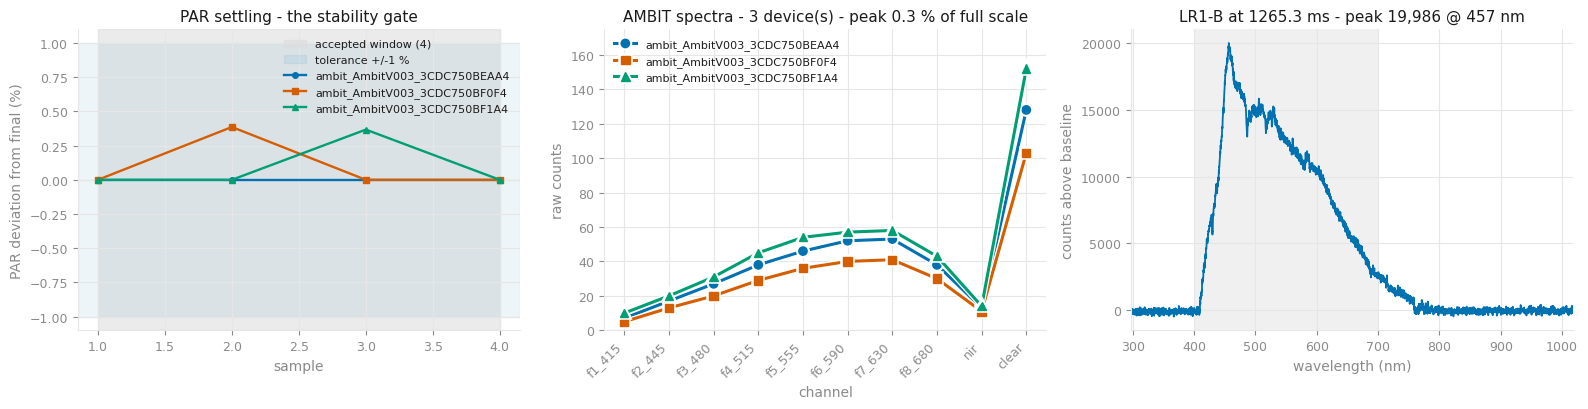

,ambit,PAR,PAR spread %,PAR p-p,peak counts,full scale,headroom,sat,leaf degC,gain,tint ms
0,ambit_AmbitV003_3CDC750BEAA4,56.778,0.000,0.000,128,50000,99.7%,False,26.1,2x,139.0
1,ambit_AmbitV003_3CDC750BF0F4,43.518,0.386,0.168,103,50000,99.8%,False,26.2,2x,139.0
2,ambit_AmbitV003_3CDC750BF1A4,65.388,0.367,0.240,152,50000,99.7%,False,26.3,2x,139.0


In [35]:
SURFACE, INK, INK_MUTED, GRID, BAND = '#ffffff', '#1b1b1b', '#8a8a8a', '#e6e6e6', '#dcdcdc'

# Okabe-Ito subset: fixed order, never cycled by rank. Each slot pairs a hue with its own
# marker, so the slots inside the CVD dE 6-8 band stay separable in greyscale and in print.
DEVICE_COLOURS = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#56B4E9', '#E69F00']
DEVICE_MARKERS = ['o', 's', '^', 'D', 'v', 'P']
DEVICE_LINES   = ['-', '--', ':']


def device_style(index):
    slot = index % len(DEVICE_COLOURS)
    return (DEVICE_COLOURS[slot], DEVICE_MARKERS[slot],
            DEVICE_LINES[(index // len(DEVICE_COLOURS)) % len(DEVICE_LINES)])


def _style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    ax.xaxis.label.set_color(INK_MUTED)
    ax.yaxis.label.set_color(INK_MUTED)
    ax.title.set_color(INK)


def plot_par_convergence(reading, ax):
    """Each AMBIT's PAR trace as % deviation from its own final value.

    Deviation rather than ratio, so the y-axis is directly comparable to STABLE_TOL and
    matplotlib never falls back to '+1' offset notation when the traces are nearly flat.
    """
    def deviation(seq):
        a = np.asarray(seq, dtype=float)
        return (a / a[-1] - 1.0) * 100 if len(a) and abs(a[-1]) > 1e-12 else a * 0.0

    n = reading['n_samples']
    accepted = min(STABLE_WINDOW, n)
    if accepted > 1:
        ax.axvspan(n - accepted + 1, n, color=BAND, alpha=0.55, zorder=0,
                   label=f'accepted window ({accepted})')
    tol = STABLE_TOL * 100
    ax.axhspan(-tol, tol, color='#0072B2', alpha=0.07, zorder=0,
               label=f'tolerance +/-{tol:g} %')
    ax.axhline(0.0, color=GRID, linewidth=1.0, zorder=1)

    order = {d.label: i for i, d in enumerate(DEVICES)}
    for label, dev in reading['devices'].items():
        colour, marker, dash = device_style(order.get(label, 0))
        series = dev['par_history']
        ax.plot(np.arange(1, len(series) + 1), deviation(series), linewidth=1.7,
                marker=marker, markersize=4, color=colour, linestyle=dash,
                label=label, zorder=2)

    ax.set_xlabel('sample')
    ax.set_ylabel('PAR deviation from final (%)')
    ax.set_title('PAR settling - the stability gate', fontsize=11)
    ax.legend(frameon=False, fontsize=8, labelcolor=INK, loc='best')
    _style(ax)


SHOW_FULL_SCALE_ABOVE = 0.5   # draw the rail only once the peak is this close to it


def plot_spectra(reading, ax):
    """Raw counts per channel. Unnormalised - every AMBIT shares the same fixed exposure,
    so counts are directly comparable between devices without rescaling.

    The y-axis follows the data, not the rail. In ordinary light the peak sits a few
    percent of full scale, and anchoring the axis at 50000 would flatten every device
    into the bottom of the panel. The rail is drawn only when it is close enough to
    matter; otherwise the headroom is stated in the title, where it stays readable.
    """
    x = np.arange(1, N_SPEC + 1)
    order = {d.label: i for i, d in enumerate(DEVICES)}
    for label, dev in reading['devices'].items():
        colour, marker, dash = device_style(order.get(label, 0))
        ax.plot(x, np.asarray(dev['raw'], dtype=float), linewidth=2.2, marker=marker,
                markersize=6, color=colour, linestyle=dash, label=label,
                path_effects=[pe.Stroke(linewidth=4, foreground=SURFACE), pe.Normal()])

    peak = max(float(np.max(d['raw'])) for d in reading['devices'].values())
    full_scales = {d['full_scale'] for d in reading['devices'].values()}
    fs = full_scales.pop() if len(full_scales) == 1 else None
    if fs and peak >= SHOW_FULL_SCALE_ABOVE * fs:
        ax.axhline(fs, color=INK_MUTED, linewidth=1.0, linestyle='--', zorder=1)
        ax.annotate(f'full scale {fs:,}', xy=(N_SPEC, fs), xytext=(-4, 4),
                    textcoords='offset points', ha='right', va='bottom',
                    fontsize=8, color=INK_MUTED)
        ax.set_ylim(0, fs * 1.08)
    else:
        ax.set_ylim(0, peak * 1.15 if peak > 0 else 1)

    headroom = f' - peak {100 * peak / fs:.1f} % of full scale' if fs else ''
    ax.set_xticks(x)
    ax.set_xticklabels(SPECTRAL_CHANNELS, rotation=45, ha='right')
    ax.set_xlabel('channel')
    ax.set_ylabel('raw counts')
    ax.set_title(f"AMBIT spectra - {len(reading['devices'])} device(s){headroom}",
                 fontsize=11)
    if len(reading['devices']) > 1:
        ax.legend(frameon=False, fontsize=8, labelcolor=INK, loc='best')
    _style(ax)


def plot_lr1b(reading, ax):
    """The LR1-B spectrum for this capture - a single series, so no legend box."""
    spectrum = reading.get('lr1b')
    if spectrum is None:
        ax.text(0.5, 0.5, 'no LR1-B connected', ha='center', va='center',
                transform=ax.transAxes, color=INK_MUTED)
        ax.set_axis_off()
        return
    srt = spectrum.sorted()
    ax.axvspan(400, 700, color=GRID, alpha=0.6, lw=0, zorder=0)
    ax.plot(srt.wavelengths, srt.counts, linewidth=1.3, color='#0072B2', zorder=2)
    ax.set_xlim(srt.wavelengths.min(), srt.wavelengths.max())
    ax.set_xlabel('wavelength (nm)')
    ax.set_ylabel('counts above baseline')
    ax.set_title(f'LR1-B at {reading["lr1b_exposure_ms"]:g} ms - peak '
                 f'{spectrum.peak:,.0f} @ {spectrum.peak_wavelength:.0f} nm', fontsize=11)
    _style(ax)


def show_capture(reading):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), facecolor=SURFACE)
    plot_par_convergence(reading, axes[0])
    plot_spectra(reading, axes[1])
    plot_lr1b(reading, axes[2])
    fig.tight_layout()
    plt.show()


def capture_table(reading):
    """The table view - identity never rests on colour alone, and it is the relief
    the low-contrast palette slots require."""
    return pd.DataFrame([
        {'ambit': label, 'PAR': round(d['par'], 3),
         'PAR spread %': round(d['par_spread'] * 100, 3),
         'PAR p-p': round(d['par_ptp'], 3),
         'peak counts': int(d['raw'].max()), 'full scale': d['full_scale'],
         'headroom': f"{d['headroom']:.1%}", 'sat': d['sat_flag'],
         'leaf degC': d['temp_leaf'],
         'gain': f"{d['gain_x']:g}x", 'tint ms': round(d['tint_ms'], 1)}
        for label, d in reading['devices'].items()])


show_capture(test_reading)
display(capture_table(test_reading))

## 10 - Capture loop

Each round: auto-gain the LR1-B, then wait for every AMBIT's PAR to hold steady at the same
time. Review the result, then type a metadata tag to save - blank discards. `q` leaves the
loop with the ports still open.

In [36]:
readings_df = load_readings()
print(f'{len(readings_df)} row(s) in {CSV_PATH}, next measurement id = {next_measurement_id()}')
print(f'{len(DEVICES)} AMBIT(s), LR1-B {"yes" if LR1BREF else "no"}')

while True:
    key = input('[Enter] capture   |   q + [Enter] quit : ').strip().lower()
    if key in {'q', 'quit', 'exit', 'esc'}:
        print('Left the capture loop. Ports are still open.')
        break

    try:
        if LR1BREF is not None:
            print('Auto-gaining the LR1-B...')
            LR1BREF.autogain(verbose=False)
            print(f'  exposure {LR1BREF.exposure_ms:g} ms')
        print('Waiting for every AMBIT PAR to settle...')
        reading = read_stable_multi(verbose=True)
    except Exception as exc:
        print(f'Capture failed: {type(exc).__name__}: {exc}')
        continue

    clear_output(wait=True)
    show_capture(reading)
    display(capture_table(reading))

    print(f"stability : {'OK' if reading['stable'] else 'NOT REACHED'} - "
          f"{reading['n_samples']} samples in {reading['elapsed_s']:.1f} s")
    if reading['lr1b'] is not None:
        print(f"LR1-B     : {reading['lr1b']}")
    hot = [l for l, d in reading['devices'].items() if d['sat_flag']]
    if hot:
        print(f"SATURATED : {', '.join(hot)} - a channel is at full scale, so its counts "
              f"and the PAR built from them are floored; shade the sensor or accept the "
              f"row as clipped")
    if not reading['stable']:
        print('WARNING   : at least one PAR was still drifting when this was taken.')

    metadata = input('metadata tag to save this capture (blank = discard): ').strip()
    if not metadata:
        print('Discarded.')
        continue

    measurement = next_measurement_id()
    lr1b_file = save_lr1b_spectrum(reading, measurement)
    rows = reading_to_rows(reading, metadata, measurement, lr1b_file)
    append_rows(rows)
    readings_df = pd.concat([readings_df, pd.DataFrame(rows, columns=CSV_COLUMNS)],
                            ignore_index=True)
    clear_output(wait=True)
    print(f'Saved measurement {measurement} ({len(rows)} rows) to {CSV_PATH}'
          + (f'\n  LR1-B spectrum -> {LR1B_DIR / lr1b_file}' if lr1b_file else '')
          + f'\n  {len(readings_df)} rows total')

Saved measurement 1 (3 rows) to c:\Users\LudovicoCaracciolo\Documents\Git-repo\ambit\data\multi_ambit_spec_lr1b.csv
  LR1-B spectrum -> c:\Users\LudovicoCaracciolo\Documents\Git-repo\ambit\data\lr1b_spectra_ambit\measurement_00001.txt
  3 rows total
Left the capture loop. Ports are still open.


## 11 - Review what was collected

In [37]:
df = load_readings()
if df.empty:
    print(f'No readings yet in {CSV_PATH}')
else:
    print(f'{len(df)} rows / {df["measurement"].nunique()} measurement(s)')
    display(df.tail(10))

    print('\nPer-AMBIT summary:')
    display(df.groupby('ambit').agg(
        rows=('par', 'size'), par_mean=('par', 'mean'), par_std=('par', 'std'),
        worst_spread_pct=('par_spread', lambda s: 100 * s.max()),
        saturated=('sat_flag', 'sum'), unstable=('stable', lambda s: (~s.astype(bool)).sum()),
    ).round(4))

    # Agreement between devices looking at the same light: the point of running
    # several at once. Spread across AMBITs within one measurement, per capture.
    per_meas = df.groupby('measurement')['par']
    rel = (per_meas.max() - per_meas.min()) / per_meas.mean().replace(0, np.nan)
    print(f'\nInter-AMBIT PAR spread within a capture: median {100 * rel.median():.2f} %, '
          f'worst {100 * rel.max():.2f} %')

3 rows / 1 measurement(s)


,timestamp,measurement,ambit,metadata,par,temp_leaf,f1_415,f2_445,f3_480,f4_515,...,saturated_channels,par_spread,par_ptp,n_samples,stable,lr1b_exposure_ms,lr1b_peak,lr1b_total,lr1b_peak_nm,lr1b_spectrum_file
0,2026-08-13T12:07:00,1,ambit_AmbitV003_3CDC750BEAA4,office,56.778000,26.1,7.0,17.0,27.0,38.0,...,NaN,0.000000,0.000,4,True,1265.3,19957.5,16079871.0,456.899,measurement_00001.txt
1,2026-08-13T12:07:00,1,ambit_AmbitV003_3CDC750BF0F4,office,43.518002,26.3,5.0,13.0,20.0,29.0,...,NaN,0.006057,0.264,4,True,1265.3,19957.5,16079871.0,456.899,measurement_00001.txt
2,2026-08-13T12:07:00,1,ambit_AmbitV003_3CDC750BF1A4,office,65.388000,26.3,10.0,20.0,31.0,45.0,...,NaN,0.000000,0.000,4,True,1265.3,19957.5,16079871.0,456.899,measurement_00001.txt



Per-AMBIT summary:


,rows,par_mean,par_std,worst_spread_pct,saturated,unstable
ambit,,,,,,
ambit_AmbitV003_3CDC750BEAA4,1,56.778,NaN,0.0000,0,0
ambit_AmbitV003_3CDC750BF0F4,1,43.518,NaN,0.6057,0,0
ambit_AmbitV003_3CDC750BF1A4,1,65.388,NaN,0.0000,0,0



Inter-AMBIT PAR spread within a capture: median 39.60 %, worst 39.60 %


## 12 - Release the instruments

In [38]:
close_links()
print('Serial ports closed and the LR1-B released. Re-run open_links() to reconnect.')

Serial ports closed and the LR1-B released. Re-run open_links() to reconnect.
